# 6. Workflow Routing Insights

Backtracks the trained RL routing agent to extract actionable process improvement recommendations.

## What this notebook does

1. **Runs the trained RL agent** for N episodes and records every routing decision
2. **Compares against a random baseline** to identify which routing choices the agent learned
3. **Identifies preferred routes** — transitions the agent takes much more often than random
4. **Identifies avoided routes** — transitions the agent learned to avoid (especially bad terminals)
5. **Generates recommendations** — translates routing patterns into actionable process rules
6. **Visualises the routing graph** — shows the agent's preferred process flow

## 6.0 Install Dependencies

In [1]:
%matplotlib inline
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'joblib', 'sb3-contrib',
])


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


0

## 6.1 Setup

In [2]:
import sys, json
from pathlib import Path

_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / 'src' / 'data_ingestion.py').exists():
        _repo_root = _p
        _src = str(_p / 'src')
        if _src not in sys.path: sys.path.insert(0, _src)
        break

# Change this to analyse a different dataset
DATASET    = 'BPIC2012'
N_EPISODES = 300

OUTPUT_DIR = _repo_root / 'output' / DATASET
print(f'Dataset:    {DATASET}')
print(f'Output dir: {OUTPUT_DIR}')

Dataset:    BPIC2012
Output dir: /mnt/hdd/Code/Git/bwa/output/BPIC2012


## 6.2 Load Model and Environment

In [3]:
import joblib
import gymnasium as gym
from sb3_contrib import MaskablePPO
from rl_env import ProcessEnv
from kpi_actions import MANAGEMENT_ACTIONS, N_MANAGEMENT_ACTIONS

twin     = joblib.load(OUTPUT_DIR / f'digital_twin_{DATASET}_train.pkl')
embedder = joblib.load(OUTPUT_DIR / f'activity_embeddings.model')

tc_path = OUTPUT_DIR / 'terminal_classification.json'
bad_terminals = set(json.load(open(tc_path))['bad_terminals']) if tc_path.exists() else None

env = ProcessEnv(twin=twin, embed_model=embedder,
                 kpi_baselines=twin.kpi_baselines,
                 bad_terminals=bad_terminals)

model_path = OUTPUT_DIR / 'rl_model' / 'best_model.zip'
model = MaskablePPO.load(model_path, env=env)

print(f'Activities:    {len(twin.activities)}')
print(f'Good terminals: {sorted(env._good_terminals)}')
print(f'Bad terminals:  {sorted(env._bad_terminals)}')
print(f'Action space:  {env.action_space}')
print(f'  Routing dim:    {env.action_space.nvec[0]} actions')
print(f'  Management dim: {env.action_space.nvec[1]} actions ({N_MANAGEMENT_ACTIONS} KPI rules)')


Activities:    24
Good terminals: ['A_ACCEPTED', 'A_APPROVED', 'A_FINALIZED', 'A_PREACCEPTED', 'O_ACCEPTED']
Bad terminals:  ['A_CANCELLED', 'A_DECLINED', 'O_CANCELLED', 'O_DECLINED']
Action space:  MultiDiscrete([24 15])
  Routing dim:    24 actions
  Management dim: 15 actions (15 KPI rules)


## 6.3 Collect Trajectories

In [4]:
from insights import collect_trajectories, episode_outcome_summary
import numpy as np

print(f'Collecting {N_EPISODES} RL trajectories...')
rl_trajs = collect_trajectories(env, model, n_episodes=N_EPISODES, deterministic=True)

print(f'Collecting {N_EPISODES} random baseline trajectories...')
rng = np.random.default_rng(42)

class RandomPolicy:
    """Random policy compatible with MultiDiscrete([max_succ, n_mgmt]) action space."""
    def predict(self, obs, action_masks=None, deterministic=True):
        import gymnasium as gym
        if isinstance(env.action_space, gym.spaces.MultiDiscrete):
            max_succ = env.action_space.nvec[0]
            routing_mask = action_masks[:max_succ]
            mgmt_mask    = action_masks[max_succ:]
            ri = int(rng.choice(np.where(routing_mask)[0]))
            mi = int(rng.choice(np.where(mgmt_mask)[0]))
            return np.array([ri, mi]), None
        else:
            valid = np.where(action_masks)[0]
            return int(rng.choice(valid)), None

random_trajs = collect_trajectories(env, RandomPolicy(), n_episodes=N_EPISODES)

rl_summary     = episode_outcome_summary(rl_trajs)
random_summary = episode_outcome_summary(random_trajs)

print(f'\n{"Metric":<25} {"Random":>10}  {"Our RL":>10}')
print('-' * 48)
for key in ['mean_reward', 'std_reward', 'terminal_rate', 'bad_terminal_rate', 'mean_length']:
    print(f'{key:<25} {random_summary[key]:>10.3f}  {rl_summary[key]:>10.3f}')



Metric                        Random      Our RL
------------------------------------------------
mean_reward                   -3.835       3.233
std_reward                     4.013       0.064
terminal_rate                  1.000       1.000
bad_terminal_rate              0.507       0.000
mean_length                    2.400      19.000


## 6.4 Routing Preference Analysis

For each `(from_activity, to_activity)` pair, compare how often the RL agent
chose it vs the random baseline.
- `preference_ratio > 1` means the agent prefers this route
- `preference_ratio < 1` means it avoids it

In [5]:
from insights import routing_preference_table
import pandas as pd

# Load real event log for impossible-transition cross-referencing
_log_path = OUTPUT_DIR / f'events_{DATASET}_train.parquet'
real_log_df = pd.read_parquet(_log_path) if _log_path.exists() else None
if real_log_df is not None:
    print(f'Loaded real log: {len(real_log_df)} events for transition validation')
else:
    print('Real log not found — transition_type will be "unknown"')

# smoothing_alpha=0.5 (Jeffreys prior) prevents 0/0 and caps extreme ratios
pref_df = routing_preference_table(rl_trajs, random_trajs,
                                   real_log_df=real_log_df, smoothing_alpha=0.5)

# Show transition type breakdown
if 'transition_type' in pref_df.columns:
    print()
    print('Transition type breakdown:')
    print(pref_df['transition_type'].value_counts().to_string())
    print()

print('Top 15 PREFERRED routes (RL >> Random):')
top_pref = pref_df[pref_df['rl_count'] >= 3].head(15)
print(top_pref[['from_activity','to_activity','rl_pct','random_pct',
                'log2_ratio','transition_type','avg_reward_rl']].to_string(index=False))

print()
print('Top 10 AVOIDED routes — learned avoidances only (not impossible transitions):')
learned_avoid = pref_df[
    (pref_df['transition_type'] == 'learned_avoid') &
    (pref_df['random_count'] >= 3)
].tail(10)
print(learned_avoid[['from_activity','to_activity','rl_pct','random_pct',
                      'log2_ratio','transition_type','avg_reward_rl']].to_string(index=False))

print()
print('Impossible transitions (in twin but not in real log):')
impossible = pref_df[pref_df['transition_type'] == 'impossible']
print(f'  {len(impossible)} transitions flagged as impossible (twin artefacts)')
if not impossible.empty:
    print(impossible[['from_activity','to_activity','rl_count','random_count']].head(10).to_string(index=False))


Loaded real log: 262200 events for transition validation

Transition type breakdown:
transition_type
learned_avoid     53
impossible        28
learned_prefer    11
neutral            2

Top 15 PREFERRED routes (RL >> Random):
                 from_activity                    to_activity  rl_pct  random_pct  log2_ratio transition_type  avg_reward_rl
           W_Nabellen offertes    W_Wijzigen contractgegevens    50.0         0.0       4.211  learned_prefer          0.250
W_Nabellen incomplete dossiers                    A_ACTIVATED    50.2         0.0       4.135  learned_prefer          0.248
          W_Valideren aanvraag                     O_SELECTED    34.8         0.0       3.763  learned_prefer          0.237
          W_Valideren aanvraag                      O_CREATED    31.9         0.0       3.638      impossible          0.250
        W_Completeren aanvraag            W_Beoordelen fraude   100.0         9.6       3.255  learned_prefer          0.249
            W_Afhandelen

## 6.5 Recommendations

In [6]:
from insights import generate_recommendations, print_insights_report, management_action_summary

rec_df  = generate_recommendations(pref_df, env, top_n=12)
mgmt_df = management_action_summary(rl_trajs, random_trajs)

print_insights_report(rec_df, rl_summary, random_summary, DATASET, mgmt_df=mgmt_df)

rec_df.to_csv(OUTPUT_DIR / 'routing_recommendations.csv', index=False)
pref_df.to_csv(OUTPUT_DIR / 'routing_preferences.csv', index=False)
mgmt_df.to_csv(OUTPUT_DIR / 'management_action_usage.csv', index=False)
print(f'Saved to {OUTPUT_DIR}')


  WORKFLOW ROUTING INSIGHTS — BPIC2012
  RL Backtracking Analysis (300 episodes)

  OUTCOME COMPARISON
  Metric                        Random      Our RL      Change
  ------------------------------------------------------------
  Mean reward                   -3.835       3.233  + +7.068
  Terminal rate                  1.000       1.000  - +0.000
  Bad terminal rate              0.507       0.000  + -0.507
  Mean length                    2.400      19.000  - +16.600

  MANAGEMENT ACTION USAGE (RL vs Random, top 8 by RL rate)
  Action                                      RL rate  Rnd rate   Ratio
  ----------------------------------------------------------------------
  relax_rules_for_low_risk                      62.3%     44.1%     1.4x
  assign_to_primary_team                        36.1%     41.4%     0.9x
  enable_cross_trained_pool                      0.6%      0.8%     0.7x
  merge_tasks_under_role                         0.6%      0.7%     0.8x
  adjust_staffing_by_case_vol

## 6.5b Management Action Usage

Compares which KPI-based management actions the RL policy uses vs random.
Actions the RL uses significantly more than random indicate learned intervention patterns.

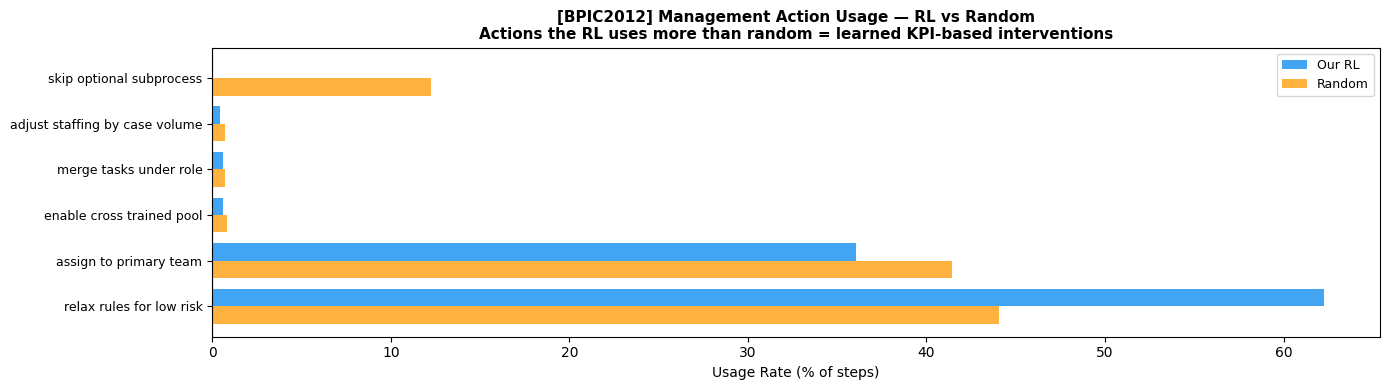

Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/management_action_usage.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

if not mgmt_df.empty:
    # Only show actions with meaningful usage (>0.5% of steps by either policy)
    sig_mgmt = mgmt_df[(mgmt_df['rl_rate'] > 0.005) | (mgmt_df['random_rate'] > 0.005)].copy()

    if not sig_mgmt.empty:
        fig, ax = plt.subplots(figsize=(14, max(4, len(sig_mgmt) * 0.55)))
        x = np.arange(len(sig_mgmt))
        bw = 0.38
        ax.barh(x + bw/2, sig_mgmt['rl_rate'] * 100,   bw, label='Our RL',  color='#2196F3', alpha=0.85)
        ax.barh(x - bw/2, sig_mgmt['random_rate'] * 100, bw, label='Random', color='#FF9800', alpha=0.75)
        ax.set_yticks(x)
        ax.set_yticklabels(sig_mgmt['mgmt_action'].str.replace('_', ' '), fontsize=9)
        ax.set_xlabel('Usage Rate (% of steps)', fontsize=10)
        ax.set_title(f'[{DATASET}] Management Action Usage — RL vs Random\n'
                     'Actions the RL uses more than random = learned KPI-based interventions',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.axvline(0, color='#555', lw=0.8)
        plt.tight_layout()
        fig.savefig(OUTPUT_DIR / 'management_action_usage.png', dpi=150, bbox_inches='tight')
        display(fig)
        plt.close(fig)
        print(f'Saved to {OUTPUT_DIR / "management_action_usage.png"}')
    else:
        print('No management actions with >0.5% usage rate.')
else:
    print('No management action data available.')


## 6.5c Decision Rules (If-Then Policy Export)

Converts the RL policy into human-readable if-then routing rules for business stakeholders.
Each rule describes the KPI context (delay level, rework, case age, volume) under which
the agent makes a specific routing decision.

Rules are sorted by `support × avg_reward` — high-frequency, high-value decisions first.

In [8]:
from insights import extract_decision_rules, print_decision_rules
import pandas as pd

rules_df = extract_decision_rules(rl_trajs, env, min_support=5, max_rules=25)
print_decision_rules(rules_df, DATASET)

# Save for business stakeholders
rules_df.to_csv(OUTPUT_DIR / 'routing_decision_rules.csv', index=False)

# Also print as a clean table
if not rules_df.empty:
    print()
    print('Decision rules table (for export):')
    display_cols = ['rank', 'from_activity', 'to_activity', 'support',
                    'avg_reward', 'condition_delay', 'condition_rework',
                    'condition_case_age', 'condition_volume']
    pd.set_option('display.max_colwidth', 40)
    print(rules_df[display_cols].to_string(index=False))
    print(f'\nSaved to {OUTPUT_DIR / "routing_decision_rules.csv"}')


  EXTRACTED ROUTING RULES — BPIC2012
  (19 rules, sorted by support × reward)

  Rule  1
  IF at 'A_SUBMITTED' AND low delay AND low rework AND early in case AND normal volume THEN route to 'A_PARTLYSUBMITTED'
  Support: 300 steps  |  Avg reward: +0.250

  Rule  2
  IF at 'A_PARTLYSUBMITTED' AND low delay AND low rework AND early in case AND normal volume THEN route to 'W_Completeren aanvraag'
  Support: 300 steps  |  Avg reward: +0.250

  Rule  3
  IF at 'W_Beoordelen fraude' AND low delay AND low rework AND early in case AND normal volume THEN route to 'W_Valideren aanvraag'
  Support: 300 steps  |  Avg reward: +0.250

  Rule  4
  IF at 'W_Valideren aanvraag' AND low delay AND low rework AND early in case AND normal volume THEN route to 'O_SENT'
  Support: 300 steps  |  Avg reward: +0.250

  Rule  5
  IF at 'W_Nabellen offertes' AND low delay AND low rework AND early in case AND normal volume THEN route to 'W_Afhandelen leads'
  Support: 300 steps  |  Avg reward: +0.250

  Rule  6
  

## 6.6 Routing Preference Heatmap

Blue = agent prefers this route over random.  
Red = agent avoids this route vs random.  
White = same as random.  
Red column borders mark bad terminal activities.

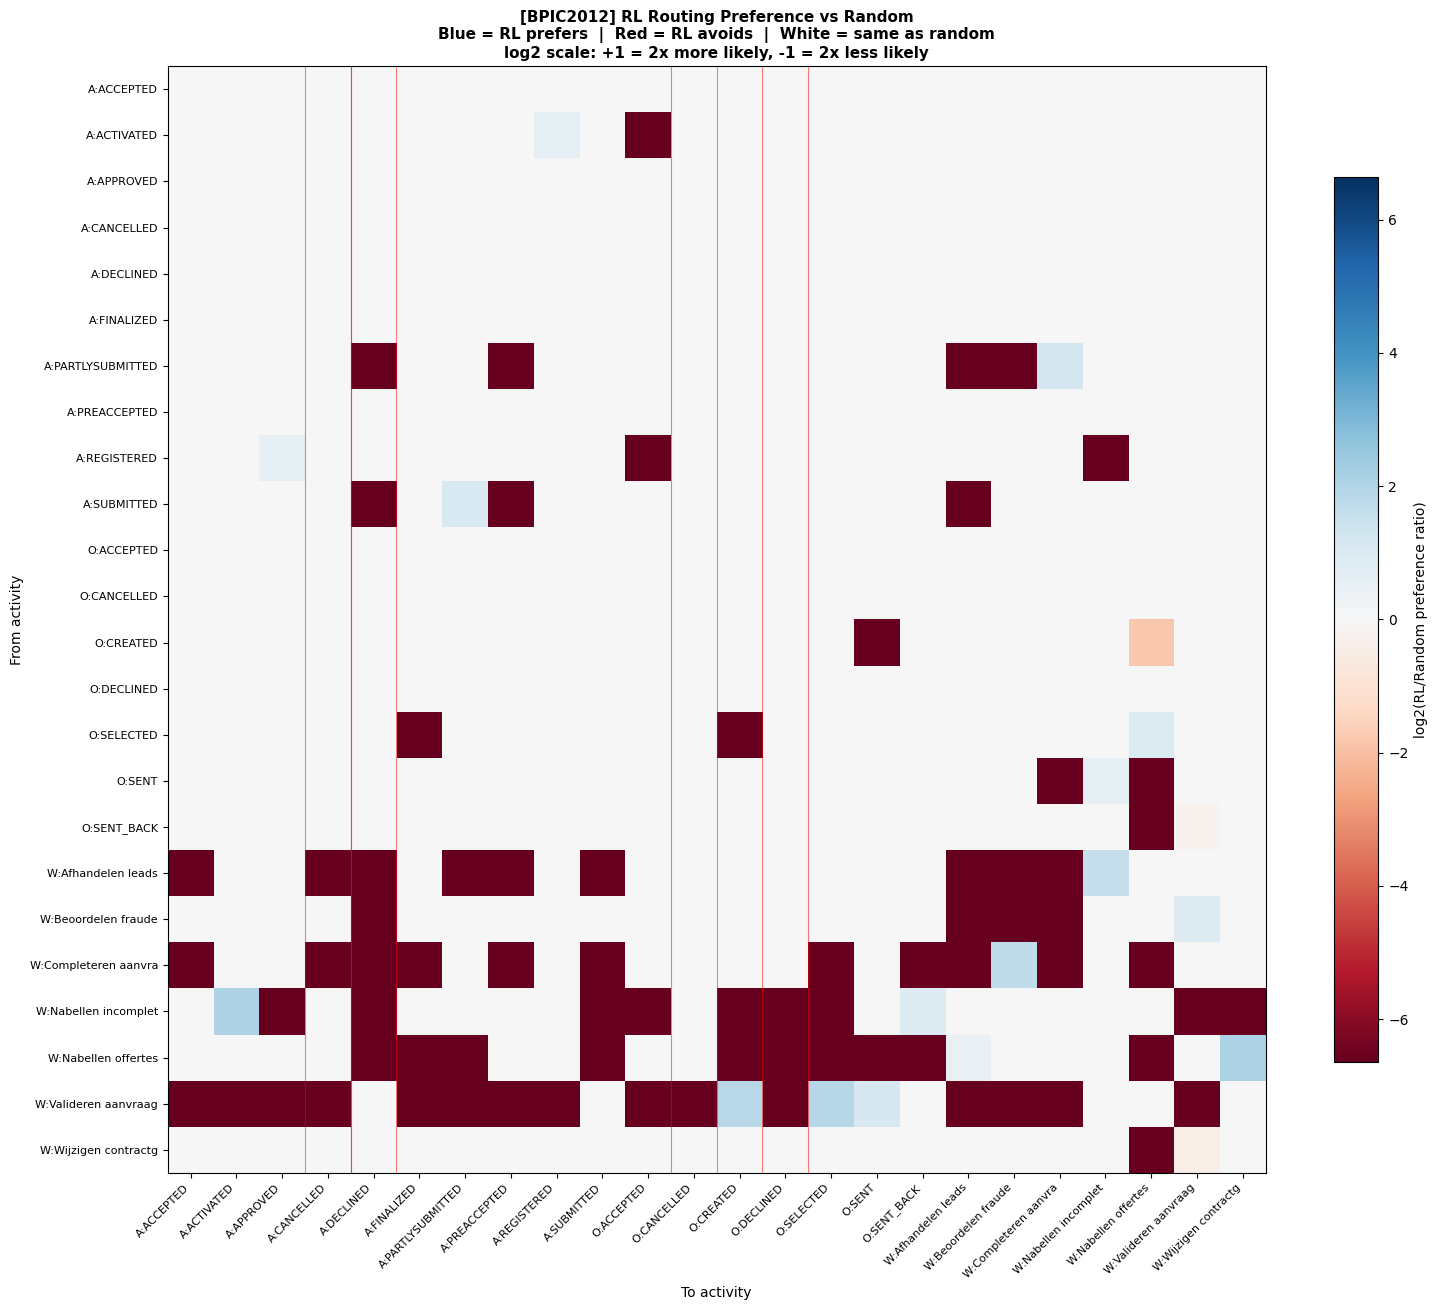

In [9]:
import matplotlib.pyplot as plt
import numpy as np

acts = sorted(twin.activities)
n = len(acts)
act_idx = {a: i for i, a in enumerate(acts)}

ratio_mat = np.zeros((n, n))
for _, row in pref_df.iterrows():
    i = act_idx.get(row['from_activity'])
    j = act_idx.get(row['to_activity'])
    if i is not None and j is not None:
        ratio_mat[i, j] = np.log2(max(row['log2_ratio'], 0.01))

fig, ax = plt.subplots(figsize=(max(10, n*0.65), max(8, n*0.55)))
vmax = max(abs(ratio_mat.max()), abs(ratio_mat.min()), 1)
im = ax.imshow(ratio_mat, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')

short = [a.replace('W_','W:').replace('A_','A:').replace('O_','O:')[:20] for a in acts]
ax.set_xticks(range(n)); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(short, fontsize=8)
ax.set_xlabel('To activity', fontsize=10)
ax.set_ylabel('From activity', fontsize=10)
ax.set_title(
    f'[{DATASET}] RL Routing Preference vs Random\n'
    'Blue = RL prefers  |  Red = RL avoids  |  White = same as random\n'
    'log2 scale: +1 = 2x more likely, -1 = 2x less likely',
    fontsize=11, fontweight='bold')

for j, act in enumerate(acts):
    if act in env._bad_terminals:
        ax.axvline(j - 0.5, color='red', lw=0.8, alpha=0.5)
        ax.axvline(j + 0.5, color='red', lw=0.8, alpha=0.5)

plt.colorbar(im, ax=ax, label='log2(RL/Random preference ratio)', shrink=0.8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'routing_preference_heatmap.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

## 6.7 Episode Outcome Distribution

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'[{DATASET}] Episode Outcome Distribution — RL vs Random',
             fontsize=12, fontweight='bold')

rl_rewards  = [t['total_reward'] for t in rl_trajs]
rnd_rewards = [t['total_reward'] for t in random_trajs]
axes[0].hist(rnd_rewards, bins=30, alpha=0.6, color='#FF9800', label='Random', density=True)
axes[0].hist(rl_rewards,  bins=30, alpha=0.6, color='#2196F3', label='Our RL', density=True)
axes[0].axvline(np.mean(rnd_rewards), color='#FF9800', lw=2, ls='--')
axes[0].axvline(np.mean(rl_rewards),  color='#2196F3', lw=2, ls='--')
axes[0].set_xlabel('Total Episode Reward'); axes[0].set_ylabel('Density')
axes[0].set_title('Reward Distribution'); axes[0].legend()

rl_lens  = [t['n_steps'] for t in rl_trajs]
rnd_lens = [t['n_steps'] for t in random_trajs]
axes[1].hist(rnd_lens, bins=30, alpha=0.6, color='#FF9800', label='Random', density=True)
axes[1].hist(rl_lens,  bins=30, alpha=0.6, color='#2196F3', label='Our RL', density=True)
axes[1].set_xlabel('Episode Length (steps)'); axes[1].set_ylabel('Density')
axes[1].set_title('Episode Length Distribution'); axes[1].legend()

rl_finals  = [t['final_activity'] for t in rl_trajs]
rnd_finals = [t['final_activity'] for t in random_trajs]
all_finals = sorted(set(rl_finals + rnd_finals))
rl_pcts  = [rl_finals.count()  / len(rl_finals)  * 100 for a in all_finals]
rnd_pcts = [rnd_finals.count(a) / len(rnd_finals) * 100 for a in all_finals]
x = np.arange(len(all_finals)); bw = 0.35
axes[2].bar(x - bw/2, rnd_pcts, bw, label='Random', color='#FF9800', alpha=0.85)
axes[2].bar(x + bw/2, rl_pcts,  bw, label='Our RL', color='#2196F3', alpha=0.85)
short_f = [a.replace('W_','W:').replace('A_','A:').replace('O_','O:')[:14] for a in all_finals]
axes[2].set_xticks(x); axes[2].set_xticklabels(short_f, rotation=45, ha='right', fontsize=7)
axes[2].set_ylabel('% of episodes'); axes[2].set_title('Final Activity Distribution')
for i, act in enumerate(all_finals):
    if act in env._bad_terminals:
        axes[2].axvspan(i - 0.5, i + 0.5, alpha=0.08, color='red')
axes[2].legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'episode_outcomes.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

TypeError: list.count() takes exactly one argument (0 given)

## 6.8 Top Routing Divergences

Horizontal bar chart of the routes where the RL agent diverges most from random.  
Value labels show the multiplier (e.g. 3.2x = RL is 3.2x more/less likely than random).

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

sig = pref_df[(pref_df['rl_count'] + pref_df['random_count']) >= 5].copy()
sig['log_ratio'] = sig['log2_ratio']
sig['route'] = sig['from_activity'].str[:18] + ' ->\n' + sig['to_activity'].str[:18]
sig = sig.reindex(sig['log_ratio'].abs().sort_values(ascending=False).index).head(20)

colors = ['#c0392b' if row['to_activity'] in env._bad_terminals
          else ('#2196F3' if row['log_ratio'] > 0 else '#e74c3c')
          for _, row in sig.iterrows()]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(sig)), sig['log_ratio'], color=colors, alpha=0.85, height=0.65)
ax.axvline(0, color='#555', lw=1.2, ls='--')
ax.set_yticks(range(len(sig)))
ax.set_yticklabels(sig['route'], fontsize=8)
ax.set_xlabel('log2(RL preference ratio)  --  positive = RL prefers, negative = RL avoids',
              fontsize=10)
ax.set_title(f'[{DATASET}] Top 20 Routing Divergences: RL vs Random\n'
             'Dark red = bad terminal route  |  Blue = RL prefers  |  Red = RL avoids',
             fontsize=11, fontweight='bold')

for bar, (_, row) in zip(bars, sig.iterrows()):
    v = row['log_ratio']
    xpos = v + 0.05 if v >= 0 else v - 0.05
    ha = 'left' if v >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{2**abs(v):.1f}x', va='center', ha=ha, fontsize=7.5)

patches = [
    mpatches.Patch(color='#2196F3', label='RL prefers (good route)'),
    mpatches.Patch(color='#e74c3c', label='RL avoids'),
    mpatches.Patch(color='#c0392b', label='Bad terminal route'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'routing_divergences.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

## 6.9 Recommendations Summary Table

In [ ]:
import pandas as pd

if not rec_df.empty:
    pd.set_option('display.max_colwidth', 120)
    pd.set_option('display.max_rows', 20)
    display_cols = ['rank', 'type', 'from_activity', 'to_activity',
                    'rl_pct', 'random_pct', 'ratio', 'recommendation']
    print(f'{len(rec_df)} recommendations for {DATASET}:')
    print(rec_df[display_cols].to_string(index=False))
else:
    print('No significant routing divergences found.')
    print('Try increasing N_EPISODES or retraining with more steps.')